# Budowa i podział zbioru danych (Dataset Creation)

W tym etapie następuje ostateczne przygotowanie danych do uczenia modeli uczenia maszynowego (KNN, SVM, CNN). Proces transformacji sygnału obejmuje przejście od ciągłych zapisów EKG do ustrukturyzowanych, poetykietowanych próbek (okien).

Główne założenia tego etapu:
1.  **Oknowanie (Windowing):** Podział sygnału na 10-sekundowe fragmenty z 5-sekundowym przesunięciem (overlap).
2.  **Etykietowanie (Labeling):** Zamiast usuwać zaszumione fragmenty, oznaczamy je jako klasę negatywną (Anomalia = 1). Sygnały poprawne otrzymują etykietę 0.
3.  **Normalizacja:** Skalowanie amplitudy sygnału do przedziału `[-1, 1]`, co jest kluczowe dla stabilności sieci neuronowych.
4.  **Podział (Splitting):** Wyodrębnienie zbiorów: Treningowego i Walidacyjnego.

In [54]:

import pandas as pd
import numpy as np
import pickle
from sklearn.model_selection import train_test_split
from pathlib import Path
import neurokit2 as nk
import seaborn as sns
import matplotlib.pyplot as plt

file_path = "z4data.pkl"

# Wczytanie danych
if Path(file_path).exists():
    print(f"Wczytywanie danych z pliku: {file_path}...")
    with open(file_path, "rb") as f:
        data_package = pickle.load(f)
    
    # Pobieramy sygnały 
    raw_garmin = data_package.get("Watch")
    clean_clinical = data_package.get("ECG")
    
    print("✅ Dane wczytane pomyślnie.")
else:
    print(f"❌ BŁĄD: Plik {file_path} nie istnieje. Uruchom kod z z2.ipynb, aby wygenerować dane.")
    raw_garmin = None
    clean_clinical = None

Wczytywanie danych z pliku: z4data.pkl...
✅ Dane wczytane pomyślnie.


## 1. Definicja funkcji przetwarzających

Zaimplementowano trzy kluczowe funkcje operujące na surowych danych:

* **`create_windows`**: Odpowiada za pocięcie ciągłego sygnału na mniejsze wektory o ustalonej długości (1280 próbek dla 10 sekund przy 128 Hz).
* **`check_anomaly_label`**: Algorytm regułowy oceniający jakość sygnału. Okno otrzymuje etykietę **1 (Anomalia)**, jeśli spełnia którykolwiek z warunków:
    * Występują braki danych (NaN).
    * Sygnał jest "martwy" (odchylenie standardowe < 0.5).
    * Występują artefakty o niefizjologicznej amplitudzie (> 3000).
    * Wykryto nagłe, nienaturalne skoki wartości (> 2000).
* **`normalize_window`**: Wykonuje normalizację Min-Max według wzoru:
    $$x_{norm} = 2 \cdot \frac{x - x_{min}}{x_{max} - x_{min}} - 1$$
    Dzięki temu sygnały z różnych urządzeń (Garmin vs Aparatura) mają tę samą skalę amplitudową.

In [55]:
def create_windows(data, window_seconds=10, step_seconds=5, fs=128):    
    window_samples = int(window_seconds * fs) 
    step_samples = int(step_seconds * fs)     
    
    # Konwersja do numpy array, jeśli dane są w DataFrame/Series
    if hasattr(data, 'values'):
        data_array = data.values
    else:
        data_array = np.array(data)

    # Upewnienie się, że tablica jest odpowiedniego kształtu
    if data_array.ndim == 1:
        data_array = data_array.reshape(-1, 1)

    total_samples = data_array.shape[0]
    windows = []
    
    for start_index in range(0, total_samples - window_samples + 1, step_samples):
        end_index = start_index + window_samples
        window = data_array[start_index:end_index]
        windows.append(window)
        
    return np.array(windows)

def check_anomaly_label(window, threshold_max_amp=3000, threshold_min_std=0.5):
    
    if np.isnan(window).any():
        return 1
    
    # Sprawdzenie czy sygnał nie jest "martwy" 
    stds = np.std(window, axis=0)
    if (stds < threshold_min_std).all():
        return 1
            
    #Sprawdzenie artefaktów
    max_val = np.max(np.abs(window))
    if max_val > threshold_max_amp:
        return 1

    #Sprawdzenie nienaturalnych skoków
    diffs = np.diff(window, axis=0)
    if (np.abs(diffs) > 2000).any(): # orginalnie 1500
        return 1
        
    return 0 

def normalize_window(window):
    """
    Normalizacja Min-Max do przedziału [-1, 1].
    Wzór: 2 * (x - min) / (max - min) - 1
    """
    min_val = np.min(window)
    max_val = np.max(window)
    
    # Zabezpieczenie przed dzieleniem przez zero 
    if max_val - min_val == 0:
        return np.zeros_like(window)
        
    return 2 * (window - min_val) / (max_val - min_val) - 1

### Generacja indeksów klasyfikujacych jakosc sygnałow
Obliczamy tylko dwa indeksy, poniewaz pracujemy na przefiltrowanym sygnale.

- cSQI
    weryfikujemy powtarzalnosc uderzen serca, czy podczas trwania okna nie dochodzi do ruchow 
    wysoka wartosc tego wspolczynnika oznacza stabilne bicie serca i stabilny pomiar 

- qSQI 
    weryfikacja poprzednio obliczonego wskaznika, spogladamy na problem z prespektywy dwoch algorytmow

In [61]:
def calculate_cSQI(window, mode='clinical'):

    if mode == 'clinical':
        window = window[:,1]
    else:
        window = window.flatten()    

   
    peaks, _ = nk.ecg_peaks(window, sampling_rate=128, method = 'neurokit')
    r_peaks = peaks['ECG_R_Peaks'].values 

    r_indicies = np.where(r_peaks == 1)[0]

    epochs = nk.ecg_segment(window, r_indicies, sampling_rate=128)

    beats = []

    for i in epochs:
        segment = epochs[i]['Signal'].dropna().values
        beats.append(segment)

    if not beats: return 0.0
    min_len = min(len(b) for b in beats)
    
    beats_matrix = np.array([b[:min_len] for b in beats])

    template_beat = np.mean(beats_matrix, axis=0)


    correlations = []
    for i in range(beats_matrix.shape[0]):
        corr = np.corrcoef(beats_matrix[i, :], template_beat)[0, 1]
        correlations.append(corr)

    csqi = np.nanmean(correlations)
    

    return max(0.0, float(csqi))


In [62]:
def calculate_qSQI(window, mode='clinical'):

    
    if mode == 'clinical':
        window = window[:,1]
    else:
        window = window.flatten()


    
    _, info_a = nk.ecg_peaks(window, sampling_rate=128, method="neurokit")
    peaks_a = info_a["ECG_R_Peaks"]
    

    _, info_b = nk.ecg_peaks(window, sampling_rate=128, method="pantompkins1985")
    peaks_b = info_b["ECG_R_Peaks"]
    

    n_a = len(peaks_a)
    n_b = len(peaks_b)
    
    if n_a == 0 or n_b == 0:
        return 0.0


    tolerance_sec = 0.3 
    tolerance_samples = int(tolerance_sec * 128)
    
    matched_beats = 0

    peaks_b_array = np.array(peaks_b)
    
    for p_a in peaks_a:

        distances = np.abs(peaks_b_array - p_a)
        
        if np.min(distances) <= tolerance_samples:
            matched_beats += 1
    
    qsqi_val = (2 * matched_beats) / (n_a + n_b)
    
    return float(qsqi_val)

In [63]:
windows_clinical = create_windows(clean_clinical)


cSqi_values = []
qSqi_values = []

for i, window in enumerate(windows_clinical):
    cSqi = calculate_cSQI(window)
    qSqi = calculate_qSQI(window)
    print(f"cSqi for window{i+1}: {cSqi}")
    print(f"qSqi for window{i+1}: {qSqi}")
    cSqi_values.append(cSqi)
    qSqi_values.append(qSqi)



cSqi for window1: 0.9857539536491597
qSqi for window1: 1.0
cSqi for window2: 0.9828947129913606
qSqi for window2: 0.967741935483871
cSqi for window3: 0.9856153264564104
qSqi for window3: 0.9655172413793104
cSqi for window4: 0.9848924297652913
qSqi for window4: 0.9629629629629629
cSqi for window5: 0.9745281766037505
qSqi for window5: 0.9629629629629629
cSqi for window6: 0.978010825999452
qSqi for window6: 0.9629629629629629
cSqi for window7: 0.9789130894564788
qSqi for window7: 1.0
cSqi for window8: 0.9684018081579391
qSqi for window8: 1.0
cSqi for window9: 0.9735887851544296
qSqi for window9: 1.0
cSqi for window10: 0.9810764776731105
qSqi for window10: 1.0
cSqi for window11: 0.9882936549473021
qSqi for window11: 1.0
cSqi for window12: 0.9821202703309198
qSqi for window12: 0.9655172413793104
cSqi for window13: 0.9817733970959707
qSqi for window13: 1.0
cSqi for window14: 0.9864343302321772
qSqi for window14: 0.967741935483871
cSqi for window15: 0.9807821711295323
qSqi for window15: 1.0
c

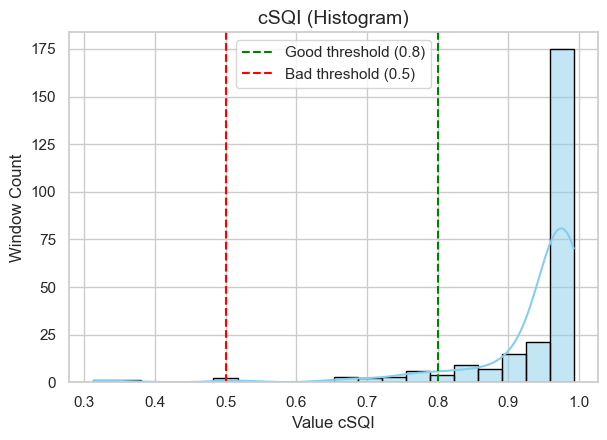

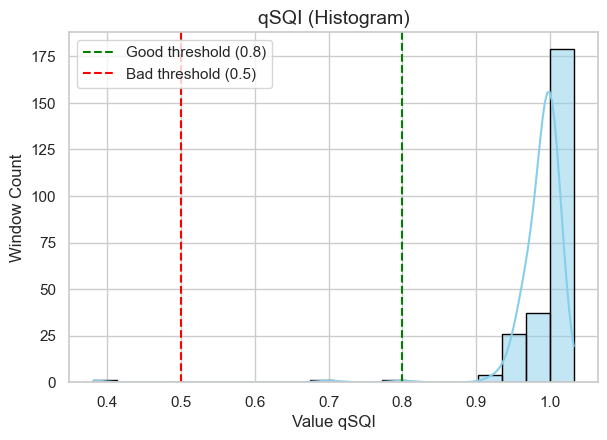

In [64]:
# Ustawienia stylu (żeby wykresy były ładne)
def visualize_indexes(index_array, name):
    sns.set_theme(style="whitegrid")
    plt.figure(figsize=(15, 10))


    plt.subplot(2, 2, 1)
    sns.histplot(index_array, bins=20, kde=True, color='skyblue', edgecolor='black')
    plt.axvline(0.8, color='green', linestyle='--', label='Good threshold (0.8)')
    plt.axvline(0.5, color='red', linestyle='--', label='Bad threshold (0.5)')
    plt.title(f"{name} (Histogram)", fontsize=14)
    plt.xlabel(f"Value {name}")
    plt.ylabel("Window Count")
    plt.legend()


visualize_indexes(cSqi_values, "cSQI")
visualize_indexes(qSqi_values, "qSQI")



## 2. Generowanie zbioru rekordów

Poniższy kod iteruje przez wszystkie dostępne sygnały z obu źródeł (**Garmin** oraz **Kliniczne EKG**). Każde wycięte okno jest poddawane ocenie jakości i normalizacji, a następnie zapisywane wraz z metadanymi (ID, źródło) do struktury danych.

In [66]:
all_records = []

# Garmin
if raw_garmin is not None:
    print("Przetwarzanie sygnału Garmin...")
    windows_garmin = create_windows(raw_garmin)
    
    for i, window in enumerate(windows_garmin):
        label = check_anomaly_label(window)
        
        # Następnie normalizujemy do przedziału [-1, 1]
        normalized_signal = normalize_window(window)
        
        # Dodajemy do zbioru
        all_records.append({
            "ID_nagrania": f"Garmin_win_{i}",
            "sygnał": normalized_signal,   
            "źródło": "garmin",
            "label": label,                 # 1 = anomalia, 0 = ok
            "qSQI": calculate_qSQI(window, mode="garmin"),
            "cSQI": calculate_cSQI(window, mode="garmin")
        })

#dane kliniczne
if clean_clinical is not None:
    print("Przetwarzanie sygnału Klinicznego...")
    windows_clinical = create_windows(clean_clinical)
    
    for i, window in enumerate(windows_clinical):
        label = check_anomaly_label(window)
        normalized_signal = normalize_window(window)
        
        all_records.append({
            "ID_nagrania": f"Clinical_win_{i}",
            "sygnał": normalized_signal,
            "źródło": "kliniczne",
            "label": label,
            "qSQI": calculate_qSQI(window, mode="garmin"),
            "cSQI": calculate_cSQI(window, mode="garmin")
        })

print(f" Zbudowano zbiór: {len(all_records)} rekordów.")

Przetwarzanie sygnału Garmin...
Przetwarzanie sygnału Klinicznego...
 Zbudowano zbiór: 254 rekordów.


## 3. Podział na zbiory (Train / Val )

Utworzony zbiór danych jest dzielony na dwie części w proporcjach:
* **80% - Zbiór Treningowy:** Służy do nauki modelu.
* **20% - Zbiór Walidacyjny:** Służy do strojenia hiperparametrów i monitorowania procesu uczenia.


Zastosowano **stratyfikację (`stratify`)**, aby zapewnić, że w każdym z podzbiorów udział procentowy anomalii i poprawnych sygnałów jest identyczny jak w zbiorze oryginalnym.

In [67]:
if all_records:
    print(f"\nPrzetworzono {len(all_records)} okien. Tworzę DataFrame...")
    df_dataset = pd.DataFrame(all_records)
    
    # statystyki przed podzialem
    print("\n--- STATYSTYKI ZBIORU ---")
    print("Liczba okien wg etykiety (0=Dobry, 1=Anomalia):")
    print(df_dataset['label'].value_counts())
    print("\nLiczba okien wg źródła:")
    print(df_dataset['źródło'].value_counts())

    
    output_dir = Path("dataset")
    output_dir.mkdir(parents=True, exist_ok=True) 

    # podział na zbiory 80% Train  20% Val
    train_df, val_df = train_test_split(
        df_dataset, 
        test_size=0.2, 
        random_state=42, 
        stratify=df_dataset['label'] 
    )

    # statystyki po podziale
    print("\n--- ROZMIARY ZBIORÓW ---")
    print(f"Treningowy (80%):  {len(train_df)} rekordów")
    print(f"Walidacyjny (20%): {len(val_df)} rekordów")
    

    # przykładowy rekord
    sample = train_df.iloc[0]
    print(f"\nPrzykładowy rekord (ID: {sample['ID_nagrania']}):")
    print(f"Źródło: {sample['źródło']}")
    print(f"Label: {sample['label']}")
    print(f"Min sygnału: {np.min(sample['sygnał']):.2f}, Max sygnału: {np.max(sample['sygnał']):.2f}")

    # zapis do pliku
    print(f"\n Zapisywanie plików do folderu '{output_dir}'...")
    train_df.to_pickle(output_dir / "dataset_train.pkl")
    val_df.to_pickle(output_dir / "dataset_val.pkl")
    
    print(" SUKCES! Operacja zakończona.")

else:
    print("Błąd")


Przetworzono 254 okien. Tworzę DataFrame...

--- STATYSTYKI ZBIORU ---
Liczba okien wg etykiety (0=Dobry, 1=Anomalia):
label
0    150
1    104
Name: count, dtype: int64

Liczba okien wg źródła:
źródło
kliniczne    249
garmin         5
Name: count, dtype: int64

--- ROZMIARY ZBIORÓW ---
Treningowy (80%):  203 rekordów
Walidacyjny (20%): 51 rekordów

Przykładowy rekord (ID: Clinical_win_48):
Źródło: kliniczne
Label: 0
Min sygnału: -1.00, Max sygnału: 1.00

 Zapisywanie plików do folderu 'dataset'...
 SUKCES! Operacja zakończona.


## 4. Weryfikacja wizualna (Visual Inspection)

W celu potwierdzenia poprawności automatycznego procesu etykietowania, przeprowadzono wyrywkową kontrolę jakości danych. Procedura weryfikacji polega na pobraniu i wyświetleniu:

1.  **3 losowych okien** ze zbioru, które algorytm zaklasyfikował jako sygnał poprawny (**Label = 0**).
2.  **3 losowych okien** ze zbioru, które algorytm uznał za anomalię (**Label = 1**).

Taka inspekcja pozwala szybko ocenić, czy do klasy "0" trafiają czytelne zapisy EKG, a do klasy "1" faktycznie trafiają sygnały uszkodzone, zaszumione lub płaskie linie.

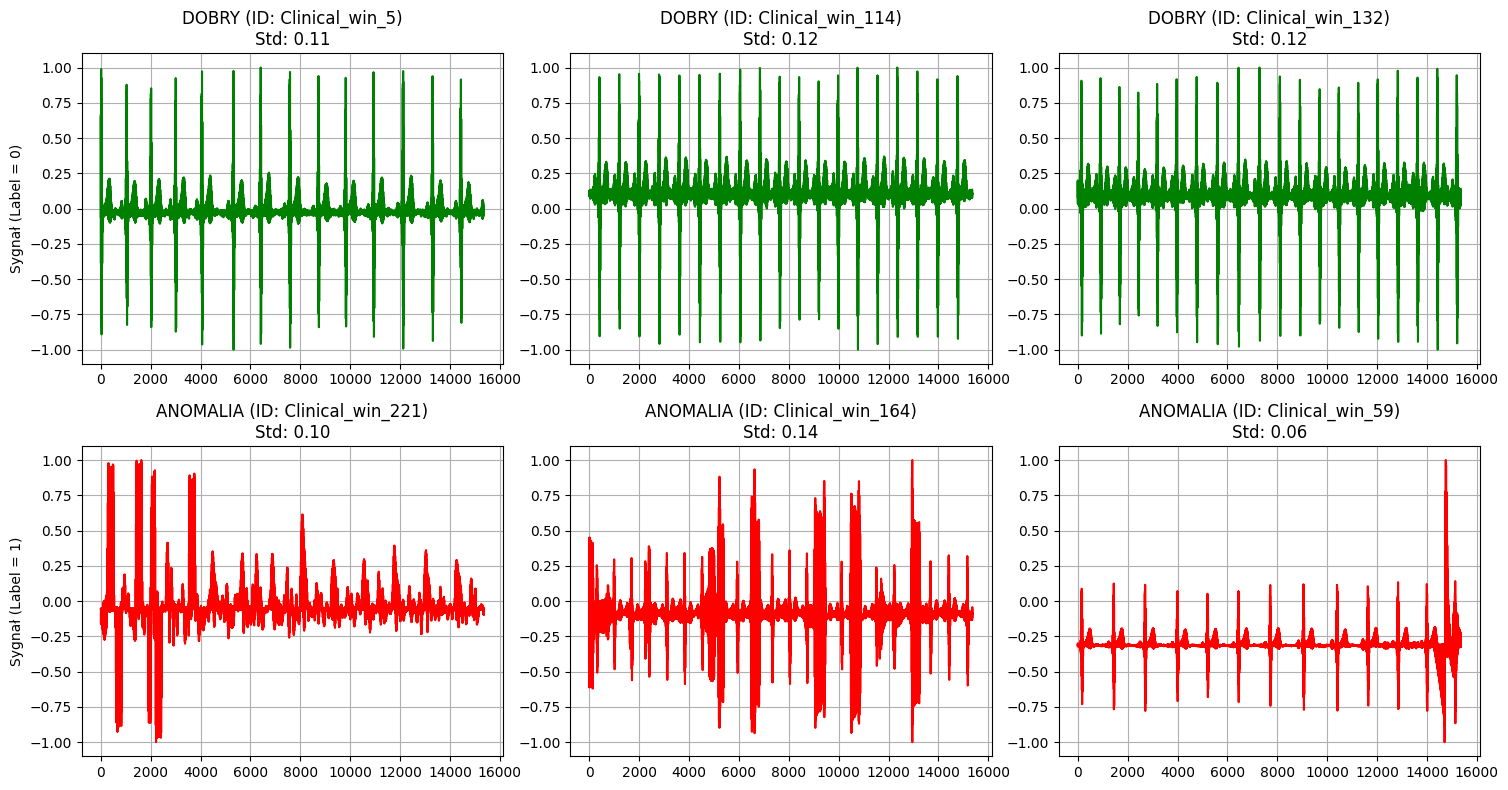

In [8]:
import matplotlib.pyplot as plt
import numpy as np

def visualize_verification(df, n_samples=3):
    # Pobieramy losowe próbki z klasy 0 (Dobre) i 1 (Anomalie)
    good_samples = df[df['label'] == 0].sample(min(n_samples, len(df[df['label']==0])))
    bad_samples = df[df['label'] == 1].sample(min(n_samples, len(df[df['label']==1])))
    
    fig, axes = plt.subplots(nrows=2, ncols=n_samples, figsize=(15, 8))
    
    # Rysowanie dobrych sygnałów
    for i, (_, row) in enumerate(good_samples.iterrows()):
        sig = row['sygnał']
        # Jeśli sygnał jest spłaszczony (1D), to OK. Jeśli (N, 1), spłaszczamy.
        if sig.ndim > 1: sig = sig.flatten()
            
        axes[0, i].plot(sig, color='green')
        axes[0, i].set_title(f"DOBRY (ID: {row['ID_nagrania']})\nStd: {np.std(sig):.2f}")
        axes[0, i].set_ylim(-1.1, 1.1)
        axes[0, i].grid(True)
        
    # Rysowanie anomali
    for i, (_, row) in enumerate(bad_samples.iterrows()):
        sig = row['sygnał']
        if sig.ndim > 1: sig = sig.flatten()
            
        axes[1, i].plot(sig, color='red')
        axes[1, i].set_title(f"ANOMALIA (ID: {row['ID_nagrania']})\nStd: {np.std(sig):.2f}")
        axes[1, i].set_ylim(-1.1, 1.1)
        axes[1, i].grid(True)
    
    axes[0, 0].set_ylabel("Sygnał (Label = 0)")
    axes[1, 0].set_ylabel("Sygnał (Label = 1)")
    plt.tight_layout()
    plt.show()

# Wywołanie weryfikacji na zbiorze treningowym
if 'train_df' in locals():
    visualize_verification(train_df)
else:
    print("błąd")

### Wnioski z weryfikacji

Powyższe wykresy prezentują przykładowe okna zaklasyfikowane do obu grup.
* **Analiza poprawnych sygnałów (Zielone):** Potwierdza, że algorytm nie odrzuca okien o wysokiej amplitudzie, jeśli zachowują one charakterystykę EKG (widoczne załamki R).
* **Analiza anomalii (Czerwone):** Wskazuje, że do tej grupy trafiają sygnały o bardzo niskiej wariancji (odłączenie elektrody) lub zawierające nieregularne, wysokoczęstotliwościowe zakłócenia.

Na podstawie wizualnej oceny, przyjęte progi detekcji (`threshold_max_amp=3000`, `threshold_min_std=0.5`) uznaje się za wystarczające do generowania zbioru uczącego.